# Deep Learning Breast Cancer Detection Using Transfer Learning and CNN-Based Mammogram Classification: A Comparitive study

## Research Question:

### To what extent can transfer learning and fine-tuning strategies improve the performance and interpretability of CNN-based breast cancer detection systems using mammogram images?

In [1]:
import pandas as pd

mass_train = pd.read_csv("mass_case_description_train_set.csv")
mass_test = pd.read_csv("mass_case_description_test_set.csv")

# Section 1.1: Mass Dataset Exploration

In [2]:
print(mass_train.columns)

Index(['patient_id', 'breast_density', 'left or right breast', 'image view',
       'abnormality id', 'abnormality type', 'mass shape', 'mass margins',
       'assessment', 'pathology', 'subtlety', 'image file path',
       'cropped image file path', 'ROI mask file path'],
      dtype='str')


In [3]:
print(mass_train['pathology'].value_counts())


pathology
MALIGNANT                  637
BENIGN                     577
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64


In [4]:
print(mass_test['pathology'].value_counts())


pathology
BENIGN                     194
MALIGNANT                  147
BENIGN_WITHOUT_CALLBACK     37
Name: count, dtype: int64


number of unique pts

In [5]:
print("Train patients:", mass_train['patient_id'].nunique())
print("Train records:", len(mass_train))

Train patients: 691
Train records: 1318


In [6]:
print("Test patients:", mass_test['patient_id'].nunique())
print("Test records:", len(mass_test))

Test patients: 201
Test records: 378


The predefined CBIS-DDSM train-test split was retained. A patient-level leakage check was performed by comparing patient identifiers across training and testing sets. No overlapping patients were found, ensuring that model evaluation was conducted on previously unseen patients.

Patient-Level Train-Test Leakage Check

In [7]:
train_patients = set(mass_train['patient_id'])
test_patients = set(mass_test['patient_id'])

overlap = train_patients.intersection(test_patients)

print("Overlapping patients:", len(overlap))

Overlapping patients: 0


In [8]:
mass_train.isnull().sum()

patient_id                  0
breast_density              0
left or right breast        0
image view                  0
abnormality id              0
abnormality type            0
mass shape                  4
mass margins               43
assessment                  0
pathology                   0
subtlety                    0
image file path             0
cropped image file path     0
ROI mask file path          0
dtype: int64

Dataset quality assessment identified minimal missing metadata. Four records contained missing values for mass shape and 43 records contained missing values for mass margins. No missing values were found in pathology labels, image paths, cropped image paths, or ROI mask paths. Since shape and margin descriptors were not used as model inputs, these missing values were retained without imputation.

Breast density

In [9]:
mass_train['breast_density'].value_counts().sort_index()

breast_density
1    287
2    585
3    337
4    109
Name: count, dtype: int64

Mass shape

In [10]:
mass_train['mass shape'].value_counts()

mass shape
IRREGULAR                                   351
OVAL                                        321
LOBULATED                                   305
ROUND                                       123
ARCHITECTURAL_DISTORTION                     80
IRREGULAR-ARCHITECTURAL_DISTORTION           45
LYMPH_NODE                                   26
ASYMMETRIC_BREAST_TISSUE                     20
FOCAL_ASYMMETRIC_DENSITY                     19
OVAL-LYMPH_NODE                               6
LOBULATED-IRREGULAR                           5
LOBULATED-LYMPH_NODE                          3
ROUND-OVAL                                    3
LOBULATED-ARCHITECTURAL_DISTORTION            2
IRREGULAR-FOCAL_ASYMMETRIC_DENSITY            2
LOBULATED-OVAL                                1
ROUND-IRREGULAR-ARCHITECTURAL_DISTORTION      1
ROUND-LOBULATED                               1
Name: count, dtype: int64

note:
Irregular masses are the most common.

This is medically sensible because irregular masses are often associated with malignancy.

A strong discussion section could later investigate whether the model performs better on irregular lesions.

Mass margins

In [11]:
mass_train['mass margins'].value_counts()

mass margins
CIRCUMSCRIBED                            305
SPICULATED                               281
ILL_DEFINED                              278
OBSCURED                                 197
MICROLOBULATED                           108
CIRCUMSCRIBED-ILL_DEFINED                 27
ILL_DEFINED-SPICULATED                    25
OBSCURED-ILL_DEFINED                      19
CIRCUMSCRIBED-OBSCURED                    19
OBSCURED-SPICULATED                        4
OBSCURED-ILL_DEFINED-SPICULATED            4
MICROLOBULATED-ILL_DEFINED                 3
MICROLOBULATED-ILL_DEFINED-SPICULATED      2
MICROLOBULATED-SPICULATED                  2
CIRCUMSCRIBED-MICROLOBULATED               1
Name: count, dtype: int64

Assessment

In [12]:
mass_train['assessment'].value_counts().sort_index()

assessment
0    129
1      1
2     77
3    279
4    533
5    299
Name: count, dtype: int64

???
The dataset contains 1,318 mass lesion records from 691 patients. Lesions exhibit varying breast densities, shapes, and margins, providing a heterogeneous classification task representative of clinical mammography.

Dataset exploration showed that CBIS-DDSM provides full mammograms, cropped lesion regions and expert-annotated ROI masks. Since the objective of this study is to compare transfer learning strategies for lesion classification rather than lesion localisation, cropped lesion images were selected as model inputs. This ensures that model performance reflects classification capability while reducing computational complexity and enabling meaningful Grad-CAM analysis against expert annotations.

Patient-Level Pathology Consistency

In [13]:
mass_train['binary_pathology'] = mass_train['pathology'].replace({
    'BENIGN': 'BENIGN',
    'BENIGN_WITHOUT_CALLBACK': 'BENIGN',
    'MALIGNANT': 'MALIGNANT'
})

print(mass_train['binary_pathology'].value_counts())

binary_pathology
BENIGN       681
MALIGNANT    637
Name: count, dtype: int64


In [14]:
mass_test['binary_pathology'] = mass_test['pathology'].replace({
    'BENIGN': 'BENIGN',
    'BENIGN_WITHOUT_CALLBACK': 'BENIGN',
    'MALIGNANT': 'MALIGNANT'
})

print(mass_test['binary_pathology'].value_counts())

binary_pathology
BENIGN       231
MALIGNANT    147
Name: count, dtype: int64


# Section 1.2: Calcification Dataset Exploration

In [15]:
calc_train = pd.read_csv("calc_case_description_train_set.csv")
calc_test = pd.read_csv("calc_case_description_test_set.csv")

In [16]:
print(calc_train.columns)

Index(['patient_id', 'breast density', 'left or right breast', 'image view',
       'abnormality id', 'abnormality type', 'calc type', 'calc distribution',
       'assessment', 'pathology', 'subtlety', 'image file path',
       'cropped image file path', 'ROI mask file path'],
      dtype='str')


checking pathology distribution

In [17]:
print(calc_train['pathology'].value_counts())

pathology
MALIGNANT                  544
BENIGN                     528
BENIGN_WITHOUT_CALLBACK    474
Name: count, dtype: int64


In [18]:
print(calc_test['pathology'].value_counts())

pathology
BENIGN                     130
MALIGNANT                  129
BENIGN_WITHOUT_CALLBACK     67
Name: count, dtype: int64


checking missing values

In [19]:
calc_train.isnull().sum()

patient_id                   0
breast density               0
left or right breast         0
image view                   0
abnormality id               0
abnormality type             0
calc type                   20
calc distribution          376
assessment                   0
pathology                    0
subtlety                     0
image file path              0
cropped image file path      0
ROI mask file path           0
dtype: int64

number of pts vs records

In [20]:
print("Train patients:", calc_train['patient_id'].nunique())
print("Train records:", len(calc_train))

Train patients: 602
Train records: 1546


In [21]:
print("Test patients:", calc_test['patient_id'].nunique())
print("Test records:", len(calc_test))

Test patients: 151
Test records: 326


patient overlap check

In [22]:
train_patients = set(calc_train['patient_id'])
test_patients = set(calc_test['patient_id'])

overlap = train_patients.intersection(test_patients)

print("Overlapping patients:", len(overlap))

Overlapping patients: 0


pathology consistency within patient

create binary labels(same as mass)

train

In [23]:
calc_train['binary_pathology'] = calc_train['pathology'].replace({
    'BENIGN': 'BENIGN',
    'BENIGN_WITHOUT_CALLBACK': 'BENIGN',
    'MALIGNANT': 'MALIGNANT'
})

print(calc_train['binary_pathology'].value_counts())

binary_pathology
BENIGN       1002
MALIGNANT     544
Name: count, dtype: int64


testing

In [24]:
calc_test['binary_pathology'] = calc_test['pathology'].replace({
    'BENIGN': 'BENIGN',
    'BENIGN_WITHOUT_CALLBACK': 'BENIGN',
    'MALIGNANT': 'MALIGNANT'
})

print(calc_test['binary_pathology'].value_counts())

binary_pathology
BENIGN       197
MALIGNANT    129
Name: count, dtype: int64


important calcification specific columns (calc hav diff descriptors)

# Section 1.3: Combined Dataset Exploration (? gotta reword idk whats this)


# New task 1- explore remaining metadata files

In [25]:
import pandas as pd

dicom_info = pd.read_csv("dicom_info.csv")
meta = pd.read_csv("meta.csv")

print("DICOM INFO")
print(dicom_info.shape)
print(dicom_info.columns)
display(dicom_info.head())

print("\nMETA")
print(meta.shape)
print(meta.columns)
display(meta.head())

DICOM INFO
(10237, 38)
Index(['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated',
       'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate',
       'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber',
       'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate',
       'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex',
       'PhotometricInterpretation', 'PixelRepresentation',
       'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID',
       'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer',
       'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription',
       'SeriesInstanceUID', 'SeriesNumber', 'SmallestImagePixelValue',
       'SpecificCharacterSet', 'StudyDate', 'StudyID', 'StudyInstanceUID',
       'StudyTime'],
      dtype='str')


,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN



META
(6775, 9)
Index(['SeriesInstanceUID', 'StudyInstanceUID', 'Modality',
       'SeriesDescription', 'BodyPartExamined', 'SeriesNumber', 'Collection',
       'Visibility', 'ImageCount'],
      dtype='str')


,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,Visibility,ImageCount
0,1.3.6.1.4.1.9590.100.1.2.117041576511324414842...,1.3.6.1.4.1.9590.100.1.2.229361142710768138411...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
1,1.3.6.1.4.1.9590.100.1.2.438738396107617880132...,1.3.6.1.4.1.9590.100.1.2.195593486612988388325...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
2,1.3.6.1.4.1.9590.100.1.2.767416741131676463382...,1.3.6.1.4.1.9590.100.1.2.257901172612530623323...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
3,1.3.6.1.4.1.9590.100.1.2.296931352612305599800...,1.3.6.1.4.1.9590.100.1.2.109468616710242115222...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
4,1.3.6.1.4.1.9590.100.1.2.436657670120353100077...,1.3.6.1.4.1.9590.100.1.2.380627129513562450304...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2


# task 2 - image inventory 

In [26]:
import os

jpeg_root = r"C:\Users\Rhithika\OneDrive\Desktop\Y3S2\CM3070_FinalProj\Dataset\Kaggle_BC_dataset\jpeg"

folder_count = 0
image_count = 0

for folder in os.listdir(jpeg_root):
    folder_path = os.path.join(jpeg_root, folder)

    if os.path.isdir(folder_path):
        folder_count += 1

        image_count += len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith(".jpg")
        ])

print("Folders:", folder_count)
print("Images:", image_count)

Folders: 6774
Images: 10237


In [27]:
from collections import Counter

images_per_folder = []

for folder in os.listdir(jpeg_root):
    folder_path = os.path.join(jpeg_root, folder)

    if os.path.isdir(folder_path):
        jpg_count = len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith(".jpg")
        ])

        images_per_folder.append(jpg_count)

print("Min images per folder:", min(images_per_folder))
print("Max images per folder:", max(images_per_folder))
print("Average images per folder:", round(sum(images_per_folder)/len(images_per_folder), 2))

print("\nDistribution:")
print(Counter(images_per_folder))

Min images per folder: 1
Max images per folder: 2
Average images per folder: 1.51

Distribution:
Counter({2: 3463, 1: 3311})


# next task :image dimension analysis 

In [28]:
import os
from PIL import Image
import pandas as pd

jpeg_root = r"C:\Users\Rhithika\OneDrive\Desktop\Y3S2\CM3070_FinalProj\Dataset\Kaggle_BC_dataset\jpeg"

widths = []
heights = []

for folder in os.listdir(jpeg_root):

    folder_path = os.path.join(jpeg_root, folder)

    if os.path.isdir(folder_path):

        for file in os.listdir(folder_path):

            if file.lower().endswith(".jpg"):

                image_path = os.path.join(folder_path, file)

                try:
                    img = Image.open(image_path)

                    widths.append(img.width)
                    heights.append(img.height)

                except:
                    pass

print("Total images analysed:", len(widths))

print("\nWidth Statistics")
print("Min:", min(widths))
print("Max:", max(widths))
print("Mean:", round(pd.Series(widths).mean(), 2))

print("\nHeight Statistics")
print("Min:", min(heights))
print("Max:", max(heights))
print("Mean:", round(pd.Series(heights).mean(), 2))

Total images analysed: 10237

Width Statistics
Min: 68
Max: 5431
Mean: 2179.89

Height Statistics
Min: 73
Max: 7111
Mean: 3549.78


In [29]:
import pandas as pd

dimension_df = pd.DataFrame({
    "width": widths,
    "height": heights
})

dimension_df.describe()

,width,height
count,10237.000000,10237.000000
mean,2179.893328,3549.778841
std,1374.221082,2363.196643
min,68.000000,73.000000
25%,453.000000,441.000000
50%,2728.000000,4624.000000
75%,3112.000000,5476.000000
max,5431.000000,7111.000000


# Next Exploration Task: Lesion Crop Dimension Analysis

In [30]:
dicom_info['SeriesDescription'].value_counts()

SeriesDescription
cropped images           3567
ROI mask images          3247
full mammogram images    2857
Name: count, dtype: int64

# final combined class distributtion

In [31]:
mass_train['binary_pathology'] = mass_train['pathology'].replace({
    'BENIGN': 'BENIGN',
    'BENIGN_WITHOUT_CALLBACK': 'BENIGN',
    'MALIGNANT': 'MALIGNANT'
})

calc_train['binary_pathology'] = calc_train['pathology'].replace({
    'BENIGN': 'BENIGN',
    'BENIGN_WITHOUT_CALLBACK': 'BENIGN',
    'MALIGNANT': 'MALIGNANT'
})

mass_counts = mass_train['binary_pathology'].value_counts()
calc_counts = calc_train['binary_pathology'].value_counts()

print("Mass")
print(mass_counts)

print("\nCalcification")
print(calc_counts)

combined_benign = (
    mass_counts['BENIGN']
    + calc_counts['BENIGN']
)

combined_malignant = (
    mass_counts['MALIGNANT']
    + calc_counts['MALIGNANT']
)

print("\nCombined")
print("BENIGN:", combined_benign)
print("MALIGNANT:", combined_malignant)

Mass
binary_pathology
BENIGN       681
MALIGNANT    637
Name: count, dtype: int64

Calcification
binary_pathology
BENIGN       1002
MALIGNANT     544
Name: count, dtype: int64

Combined
BENIGN: 1683
MALIGNANT: 1181


# where did this comefrom omg the one below

## 2.7 Cropped Image Dimension Analysis

In [32]:
# Cropped images only

cropped_info = dicom_info[
    dicom_info['SeriesDescription'] == 'cropped images'
]

print("Number of cropped images:", len(cropped_info))

print("\nWidth (Columns)")
print(cropped_info['Columns'].describe())

print("\nHeight (Rows)")
print(cropped_info['Rows'].describe())

Number of cropped images: 3567

Width (Columns)
count    3567.000000
mean      423.731147
std       321.425267
min        68.000000
25%       241.000000
50%       340.000000
75%       481.000000
max      2893.000000
Name: Columns, dtype: float64

Height (Rows)
count    3567.000000
mean      417.661060
std       337.753472
min        73.000000
25%       241.000000
50%       337.000000
75%       467.000000
max      3841.000000
Name: Rows, dtype: float64


In [33]:
# Easier-to-read summary

print("Cropped Image Width")
print("Min:", cropped_info['Columns'].min())
print("Max:", cropped_info['Columns'].max())
print("Median:", cropped_info['Columns'].median())
print("Mean:", round(cropped_info['Columns'].mean(), 2))

print("\nCropped Image Height")
print("Min:", cropped_info['Rows'].min())
print("Max:", cropped_info['Rows'].max())
print("Median:", cropped_info['Rows'].median())
print("Mean:", round(cropped_info['Rows'].mean(), 2))

Cropped Image Width
Min: 68
Max: 2893
Median: 340.0
Mean: 423.73

Cropped Image Height
Min: 73
Max: 3841
Median: 337.0
Mean: 417.66


# ---------------------------DATA PREPROCESS OFFFICIALLY BEGINS---------------------------------

# 2.1 Binary Label Mapping

In [34]:
# Convert the original pathology labels into binary classes
# BENIGN_WITHOUT_CALLBACK is merged with BENIGN

label_mapping = {
    'BENIGN': 'BENIGN',
    'BENIGN_WITHOUT_CALLBACK': 'BENIGN',
    'MALIGNANT': 'MALIGNANT'
}

mass_train['binary_pathology'] = mass_train['pathology'].map(label_mapping)
mass_test['binary_pathology'] = mass_test['pathology'].map(label_mapping)

calc_train['binary_pathology'] = calc_train['pathology'].map(label_mapping)
calc_test['binary_pathology'] = calc_test['pathology'].map(label_mapping)

verify :

In [35]:
# Check the distribution of the new binary labels
print(mass_train['binary_pathology'].value_counts())
print(calc_train['binary_pathology'].value_counts())

binary_pathology
BENIGN       681
MALIGNANT    637
Name: count, dtype: int64
binary_pathology
BENIGN       1002
MALIGNANT     544
Name: count, dtype: int64


# 2.2 Combine Mass and Calcification Datasets

In [36]:
# Combine mass and calcification datasets
# This creates a single dataset for binary lesion classification

train_df = pd.concat(
    [mass_train, calc_train],
    ignore_index=True
)

test_df = pd.concat(
    [mass_test, calc_test],
    ignore_index=True
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (2864, 18)
Test: (704, 18)


# 2.3 Label Encoding

In [37]:
# Convert class labels into numerical values
# BENIGN = 0
# MALIGNANT = 1

label_encoder = {
    'BENIGN': 0,
    'MALIGNANT': 1
}

train_df['label'] = train_df['binary_pathology'].map(label_encoder)
test_df['label'] = test_df['binary_pathology'].map(label_encoder)

verify: 

In [38]:
# Verify the numerical label distribution
train_df['label'].value_counts()

label
0    1683
1    1181
Name: count, dtype: int64

# 2.4 Train-Validation Split

In [39]:
from sklearn.model_selection import train_test_split

# Split the training dataset into training and validation sets
# Stratification preserves the class distribution in both subsets
train_split, val_split = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df['label'],
    random_state=42
)

checking:

In [40]:
# Check the number of samples in each dataset
print("Training:", train_split.shape)
print("Validation:", val_split.shape)
print("Test:", test_df.shape)

Training: (2291, 19)
Validation: (573, 19)
Test: (704, 19)


#### to check(probably delete later)

In [41]:
train_df.columns

Index(['patient_id', 'breast_density', 'left or right breast', 'image view',
       'abnormality id', 'abnormality type', 'mass shape', 'mass margins',
       'assessment', 'pathology', 'subtlety', 'image file path',
       'cropped image file path', 'ROI mask file path', 'binary_pathology',
       'breast density', 'calc type', 'calc distribution', 'label'],
      dtype='str')

next investigation:

In [42]:
# Look at a few crop paths

# train_df['cropped image file path'].head()

## 2.5 Image Path Generation (actual)

Dataset Structure Investigation

The JPEG repository contains folders corresponding to image UIDs.
Folders may contain:
- Full mammogram images
- ROI mask images
- Cropped lesion images

Several samples were manually inspected to determine the relationship
between metadata paths and JPEG image files before constructing the
automated image path generation function.

In [43]:
# ============================================================
# 2.5 Image Path Generation
# ============================================================

import os


# Generate the JPEG crop image path from a metadata path

def get_crop_image_path(metadata_path):

    parts = metadata_path.split('/')

    jpeg_folder = parts[2]

    folder_path = os.path.join(jpeg_root, jpeg_folder)

    # Skip records with missing folders
    if not os.path.exists(folder_path):
        return None

    jpg_files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith('.jpg')
    ])

    # Two-image folders contain crop + ROI mask
    # Select the crop image

    if len(jpg_files) == 2:

        return os.path.join(
            folder_path,
            jpg_files[0]
        )

    elif len(jpg_files) == 1:

        return os.path.join(
            folder_path,
            jpg_files[0]
        )

    return None

Verification
Purpose

Confirm that the function returns a valid image path.

In [44]:
# Verify image path generation

sample_image_path = get_crop_image_path(
    train_split['cropped image file path'].iloc[0]
)

print(sample_image_path)

C:\Users\Rhithika\OneDrive\Desktop\Y3S2\CM3070_FinalProj\Dataset\Kaggle_BC_dataset\jpeg\1.3.6.1.4.1.9590.100.1.2.104951888613508627920444169451577433055\1-094.jpg


Visual Verification
Purpose

Confirm that the generated path loads a lesion crop image.

Image size: (289, 257)


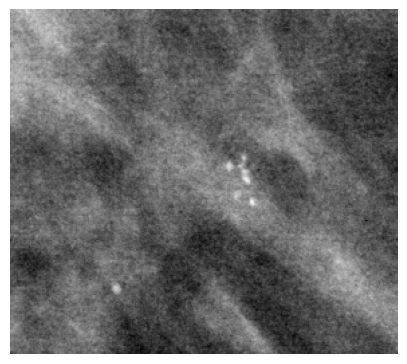

In [45]:
#not part of 2.5

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(sample_image_path)

print("Image size:", img.size)

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

## 2.6 Generate Image Paths for All Datasets(actual)

Purpose

Generate the lesion crop image path for every sample in the training, validation and test datasets.

In [46]:
# ============================================================
# 2.6 Generate Image Paths for All Datasets
# ============================================================

# Generate image paths for all datasets

# ============================================================
# 2.6 Generate Image Paths for All Datasets
# ============================================================

# Generate image paths for all datasets

train_split['image_path'] = train_split[
    'cropped image file path'
].apply(get_crop_image_path)

val_split['image_path'] = val_split[
    'cropped image file path'
].apply(get_crop_image_path)

test_df['image_path'] = test_df[
    'cropped image file path'
].apply(get_crop_image_path)

In [47]:
# Check for missing image paths

print("Training:", train_split['image_path'].isnull().sum())
print("Validation:", val_split['image_path'].isnull().sum())
print("Test:", test_df['image_path'].isnull().sum())

Training: 1
Validation: 0
Test: 0


During preprocessing, image paths were generated from the CBIS-DDSM metadata. One training record did not have a corresponding JPEG image folder and was excluded from subsequent analysis.

### 2.6.1 Remove Records with Missing Images

In [48]:
# Remove records with missing image paths

train_split = train_split.dropna(
    subset=['image_path']
).reset_index(drop=True)

val_split = val_split.dropna(
    subset=['image_path']
).reset_index(drop=True)

test_df = test_df.dropna(
    subset=['image_path']
).reset_index(drop=True)

In [49]:
# Verify final dataset sizes

print("Training:", train_split.shape)
print("Validation:", val_split.shape)
print("Test:", test_df.shape)

Training: (2290, 20)
Validation: (573, 20)
Test: (704, 20)


In [50]:
#final verification
# Verify no missing image paths remain

print("Training:", train_split['image_path'].isnull().sum())
print("Validation:", val_split['image_path'].isnull().sum())
print("Test:", test_df['image_path'].isnull().sum())

Training: 0
Validation: 0
Test: 0


temporary running stuff to be deleted later

# 2.7 Image Preprocessing Design and Implementation

## 2.7.1 Image Loading Function

In [51]:
# ============================================================
# 2.7.1 Image Loading Function
# ============================================================

from PIL import Image
import numpy as np

# Load and preprocess an image

def load_image(image_path):

    # Open image
    image = Image.open(image_path)

    # Convert to RGB
    image = image.convert("RGB")

    # Resize image
    image = image.resize((224, 224))

    # Convert to NumPy array
    image = np.array(image)

    return image

## 2.7.2 Verify Image Preprocessing

Shape: (224, 224, 3)


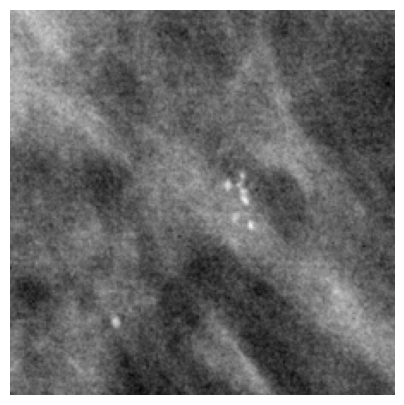

In [52]:
# Display a sample preprocessed image

sample_image_path = train_split[
    'image_path'
].iloc[0]

image = load_image(sample_image_path)

print("Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis('off')
plt.show()

## Temporary Investigation

In [53]:
# Check the files for the first training image

sample_path = train_split[
    'cropped image file path'
].iloc[0]

parts = sample_path.split('/')

jpeg_folder = parts[2]

folder_path = os.path.join(
    jpeg_root,
    jpeg_folder
)

image_files = sorted([
    f for f in os.listdir(folder_path)
    if f.lower().endswith(".jpg")
])

print(image_files)

['1-094.jpg', '2-072.jpg']


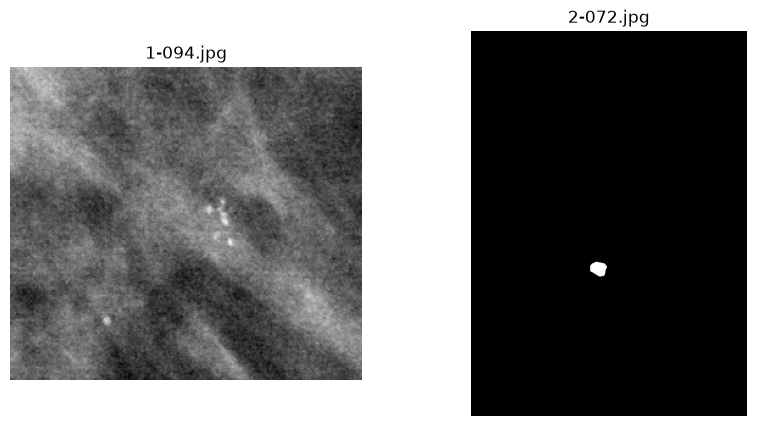

In [54]:
# Display all images in the folder

fig, axes = plt.subplots(
    1,
    len(image_files),
    figsize=(10,5)
)

for i, file in enumerate(image_files):

    img_path = os.path.join(
        folder_path,
        file
    )

    img = Image.open(img_path)

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(file)
    axes[i].axis('off')

plt.show()

### 2.7.3 Training Data Augmentation (I created augmentation object)

In [55]:
# ============================================================
# 2.7.3 Training Data Augmentation
# ============================================================

import tensorflow as tf

# Data augmentation for training images

data_augmentation = tf.keras.Sequential([

    # Small random rotations
    tf.keras.layers.RandomRotation(
        factor=0.05
    ),

    # Small horizontal and vertical shifts
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),

    # Small zoom augmentation
    tf.keras.layers.RandomZoom(
        height_factor=0.05,
        width_factor=0.05
    )

])

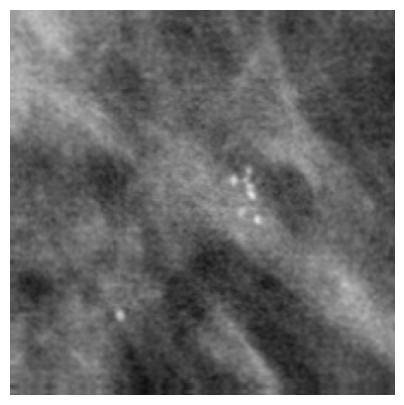

In [56]:
# Quick verification of augmentation

sample_image = load_image(
    train_split['image_path'].iloc[0]
)

sample_image = tf.expand_dims(
    sample_image,
    axis=0
)

augmented_image = data_augmentation(
    sample_image
)

plt.figure(figsize=(5,5))

plt.imshow(
    augmented_image[0].numpy().astype("uint8")
)

plt.axis('off')
plt.show()

### 2.7.4 Normalisation Strategy (Design Decision)

In [57]:
# ============================================================
# 2.7.4 Normalisation Strategy
# ============================================================

# Baseline CNN
# Pixel values will be scaled to [0,1]
# using image / 255.0

# VGG16
# Uses tf.keras.applications.vgg16.preprocess_input()

# ResNet50
# Uses tf.keras.applications.resnet50.preprocess_input()

# Model-specific preprocessing is used to ensure
# compatibility with pretrained ImageNet weights.

## 2.8 Class Weight Calculation

In [58]:
# ============================================================
# 2.8 Class Weight Calculation
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

#whats happening :
# Calculate class weights to reduce the effect
# of class imbalance during model training

# Higher weight is assigned to the minority class

# These weights will later be passed into
# model.fit(class_weight=class_weights)




# Calculate class weights from training labels

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_split['label']),
    y=train_split['label']
)

# Convert to dictionary format for Keras

class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weights)

{0: np.float64(0.8513011152416357), 1: np.float64(1.2116402116402116)}


In [59]:
# Display class weights

print("BENIGN (0):", class_weights[0])
print("MALIGNANT (1):", class_weights[1])

BENIGN (0): 0.8513011152416357
MALIGNANT (1): 1.2116402116402116


# 3.Dataset preperation for training

## 3.1 Dataset Preparation for Training
Purpose

Convert image paths and labels into a format suitable for model training

In [60]:
# ============================================================
# 3.1 Dataset Preparation for Training
# ============================================================

# Extract image paths

train_paths = train_split['image_path'].values

val_paths = val_split['image_path'].values

test_paths = test_df['image_path'].values


# Extract labels

train_labels = train_split['label'].values

val_labels = val_split['label'].values

test_labels = test_df['label'].values

In [61]:
# Verify dataset sizes

print("Training Images:", len(train_paths))
print("Validation Images:", len(val_paths))
print("Test Images:", len(test_paths))

Training Images: 2290
Validation Images: 573
Test Images: 704


## 3.2 TensorFlow Dataset Pipeline
Purpose:
Create reusable TensorFlow datasets for:

Training

Validation

Testing

which can later be fed into:

CNN

VGG16

ResNet50

### 3.2.1 Training Configuration

In [62]:
# ============================================================
# 3.2.1 Training Configuration
# ============================================================

# Image dimensions

IMG_HEIGHT = 224
IMG_WIDTH = 224

# Training batch size

BATCH_SIZE = 32

### 3.2.2 Image Loading Function for TensorFlow

In [63]:
# ============================================================
# 3.2.2 TensorFlow Image Loader
# ============================================================

import tensorflow as tf

# Load and preprocess image

def process_image(image_path, label):

    # Read image file
    image = tf.io.read_file(image_path)

    # Decode JPEG image
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize image
    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    return image, label

### 3.2.3 Create TensorFlow Datasets

In [64]:
# ============================================================
# 3.2.3 Create TensorFlow Datasets
# ============================================================

# Training dataset

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

# Validation dataset

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

# Test dataset

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

### 3.2.4 Apply Image Processing

In [65]:
# Apply image preprocessing

train_dataset = train_dataset.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

### 3.2.5 Batch and Prefetch

In [66]:
# Batch datasets

train_dataset = train_dataset.batch(
    BATCH_SIZE
)

val_dataset = val_dataset.batch(
    BATCH_SIZE
)

test_dataset = test_dataset.batch(
    BATCH_SIZE
)

# Improve training performance

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [67]:
# Verify dataset pipeline

for images, labels in train_dataset.take(1):

    print("Image batch shape:", images.shape)

    print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


## 4. Model Design and Implementation

## 4.1 Baseline CNN Architecture

In [68]:
# ============================================================
# 4.1 Baseline CNN Architecture
# ============================================================

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Rescaling,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

# Build baseline CNN

cnn_model = Sequential([

    # Define input image size
    Input(shape=(224, 224, 3)),

    data_augmentation,

    # Normalise pixel values to [0,1]
    Rescaling(1./255),

    # Convolution Block 1
    Conv2D(
        32,
        (3,3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D(),

    # Convolution Block 2
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D(),

    # Convolution Block 3
    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D(),

    # Reduce feature maps into a compact feature vector
    GlobalAveragePooling2D(),

    # Fully connected layer for classification
    Dense(
    128,
    activation='relu'
    ),

    # Reduce overfitting
    Dropout(0.5),

   
    # Binary classification output
    Dense(
    1,
    activation='sigmoid'
    )
],name="Baseline_CNN")

In [69]:
# Build model
cnn_model.build(
    input_shape=(None, 224, 224, 3)
)

# Display model summary
cnn_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

#### Compile Basline CNN

In [70]:
# ============================================================
# 4.1 Baseline CNN
# ============================================================

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import (
    Precision,
    Recall,
    AUC
)

# Compile the baseline CNN

cnn_model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

In [102]:
# Use Adam optimizer for model training

# Binary crossentropy is used because
# this is a binary classification task

# Track multiple evaluation metrics
# throughout training    WHAT IS THIS CELL?

In [103]:
# ============================================================
# 4.1 Baseline CNN
# Training Callbacks
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# Stop training if validation loss does not improve

early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

# Save the best model during training

model_checkpoint = ModelCheckpoint(

    filepath='best_baseline_cnn.keras',

    monitor='val_loss',

    save_best_only=True
)

In [104]:
# ============================================================
# 4.1 Baseline CNN
# Model Training
# ============================================================

history = cnn_model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=30,

    class_weight=class_weights,

    callbacks=[
        early_stopping,
        model_checkpoint
    ]
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.5476 - auc: 0.5658 - loss: 0.7506 - precision: 0.4589 - recall: 0.5376 - val_accuracy: 0.5881 - val_auc: 0.5976 - val_loss: 0.6793 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.5664 - auc: 0.5948 - loss: 0.6976 - precision: 0.4786 - recall: 0.5693 - val_accuracy: 0.5881 - val_auc: 0.5867 - val_loss: 0.6996 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.5803 - auc: 0.6108 - loss: 0.6858 - precision: 0.4924 - recall: 0.5450 - val_accuracy: 0.6056 - val_auc: 0.5877 - val_loss: 0.6872 - val_precision: 0.6923 - val_recall: 0.0763
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.5729 - auc: 0.6035 - loss: 0.6875 - precision: 0.4848 - recall: 0.5587 - val_accuracy: 0.6056 - val_auc: 0.6486 - val_loss: 0.6528 - val_precision: 0.6786 - val_recall: 0.0805
Epoch 5/30
72/72 ━━━━━━

The baseline CNN demonstrates moderate learning capability,
achieving validation AUC values around 0.65–0.67.

Performance remains limited, suggesting that more advanced
transfer learning architectures may offer substantial
improvements.

### CNN Baseline Evaluation

In [105]:
# ============================================================
# 4.1 Baseline CNN Evaluation [rhitz check]
# ============================================================

test_results = cnn_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nTest Results")
for metric_name, value in zip(
    cnn_model.metrics_names,
    test_results
):
    print(f"{metric_name}: {value:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step - accuracy: 0.6051 - auc: 0.5789 - loss: 0.6696 - precision: 0.4941 - recall: 0.3043

Test Results
loss: 0.6696
compile_metrics: 0.6051


Researcher Interpretation YURRRR

The first thing that jumps out is:

Precision = 0.6667
Recall = 0.0580

The model is being extremely conservative when predicting malignant cases.

In plain English:

When it predicts malignant,
it is often correct.

But it is missing most malignant cases.

For breast cancer detection:

Low recall
=
Bad

because missed cancers are generally more concerning than false alarms.

This is exactly why accuracy alone is not enough.

#### confusion matrix and classification report

In [106]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Predict probabilities
y_prob = cnn_model.predict(test_dataset)

# Convert probabilities to class labels
y_pred = (y_prob > 0.5).astype(int)

# Get true labels
y_true = []

for _, labels in test_dataset:
    y_true.extend(labels.numpy())

# Confusion Matrix
print(confusion_matrix(y_true, y_pred))

# Classification Report
print(classification_report(y_true, y_pred))

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step
[[342  86]
 [192  84]]
              precision    recall  f1-score   support

           0       0.64      0.80      0.71       428
           1       0.49      0.30      0.38       276

    accuracy                           0.61       704
   macro avg       0.57      0.55      0.54       704
weighted avg       0.58      0.61      0.58       704



Research Interpretation
:

The baseline CNN achieved a test accuracy of 61.9% and an AUC of 0.582. While the model demonstrated strong performance in identifying benign cases (recall = 0.98), it exhibited extremely low sensitivity towards malignant cases (recall = 0.06), misclassifying the majority of cancerous lesions. These findings suggest that a simple CNN trained from scratch struggles to learn sufficiently discriminative representations from the mammogram dataset, highlighting the potential value of transfer learning approaches.

## 4.2 VGG16

#### Dataset preperation (verify)

In [73]:
# ============================================================
# 4.2 VGG16 Frozen
# Image Preprocessing
# ============================================================

from tensorflow.keras.applications.vgg16 import preprocess_input

def process_image_vgg(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [224, 224]
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = preprocess_input(image)

    return image, label

In [108]:
#Create VGG16 datasets

In [74]:
# Training dataset

train_dataset_vgg = tf.data.Dataset.from_tensor_slices(
    (
        train_split['image_path'].values,
        train_split['label'].values
    )
)

train_dataset_vgg = (
    train_dataset_vgg
    .map(process_image_vgg,
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation dataset

val_dataset_vgg = tf.data.Dataset.from_tensor_slices(
    (
        val_split['image_path'].values,
        val_split['label'].values
    )
)

val_dataset_vgg = (
    val_dataset_vgg
    .map(process_image_vgg,
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

# Test dataset

test_dataset_vgg = tf.data.Dataset.from_tensor_slices(
    (
        test_df['image_path'].values,
        test_df['label'].values
    )
)

test_dataset_vgg = (
    test_dataset_vgg
    .map(process_image_vgg,
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

### 4.2.1 Frozen

In [75]:
# ============================================================
# 4.2 VGG16 Frozen - build base model
# ============================================================

from tensorflow.keras.applications import VGG16

# Load pretrained VGG16 model

vgg_base = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3)
)

# Freeze all pretrained layers

for layer in vgg_base.layers:
    layer.trainable = False

print("Trainable layers:",
      sum(layer.trainable for layer in vgg_base.layers))

Trainable layers: 0


In [76]:
#build VGG16 Frozen Model

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

vgg16_frozen = Sequential([

    Input(shape=(224, 224, 3)),

    vgg_base,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

], name="VGG16_Frozen")

vgg16_frozen.summary()

Model: "VGG16_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [112]:
#compile using th esame setting as the CNN? (delete this comment later)

In [77]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import (
    Precision,
    Recall,
    AUC
)

# Compile the VGG16 Frozen model
vgg16_frozen.compile(

    # Adam optimizer for model training
    optimizer=Adam(
        learning_rate=0.001
    ),

    # Binary classification loss function
    loss='binary_crossentropy',

    # Evaluation metrics tracked during training
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

In [114]:
# Stop training if validation loss does not improve
early_stopping_vgg = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Save the best-performing VGG16 Frozen model
model_checkpoint_vgg = ModelCheckpoint(
    filepath='best_vgg16_frozen.keras',
    monitor='val_loss',
    save_best_only=True
)

In [115]:
# Train the VGG16 Frozen model
history_vgg16_frozen = vgg16_frozen.fit(

    # Training dataset
    train_dataset_vgg,

    # Validation dataset
    validation_data=val_dataset_vgg,

    # Maximum number of training epochs
    epochs=30,

    # Handle class imbalance
    class_weight=class_weights,

    # Training callbacks
    callbacks=[
        early_stopping_vgg,
        model_checkpoint_vgg
    ]
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 289s 4s/step - accuracy: 0.5633 - auc: 0.6032 - loss: 0.8168 - precision: 0.4759 - recall: 0.5746 - val_accuracy: 0.6614 - val_auc: 0.7347 - val_loss: 0.5860 - val_precision: 0.5745 - val_recall: 0.6864
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 286s 4s/step - accuracy: 0.6144 - auc: 0.6719 - loss: 0.6461 - precision: 0.5270 - recall: 0.6402 - val_accuracy: 0.6614 - val_auc: 0.7368 - val_loss: 0.5864 - val_precision: 0.5745 - val_recall: 0.6864
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 299s 4s/step - accuracy: 0.6275 - auc: 0.7065 - loss: 0.6128 - precision: 0.5396 - recall: 0.6635 - val_accuracy: 0.6667 - val_auc: 0.7511 - val_loss: 0.5766 - val_precision: 0.5743 - val_recall: 0.7373
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 291s 4s/step - accuracy: 0.6489 - auc: 0.7387 - loss: 0.5861 - precision: 0.5591 - recall: 0.7058 - val_accuracy: 0.6702 - val_auc: 0.7562 - val_loss: 0.5717 - val_precision: 0.5761 - val_recall: 0.7542
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━

Compared with the baseline CNN, the frozen VGG16 model demonstrated substantially improved learning behaviour, with validation AUC increasing from approximately 0.58 to around 0.76. Validation recall also improved considerably, suggesting that pretrained ImageNet features provide a more discriminative representation for mammogram classification than a CNN trained from scratch.

### 4.2.2 Partial Fine-Tuning

#### Configure Partial Fine-Tuning

In [79]:
# ============================================================
# 4.2.2 VGG16 Partial Fine-Tuning
# ============================================================

from tensorflow.keras.applications import VGG16

# Load pretrained VGG16 model

vgg_base_partial = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3)

)

# Freeze all pretrained layers
for layer in vgg_base_partial.layers:
    layer.trainable = False

# Fine-tune the final convolutional block
for layer in vgg_base_partial.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

In [80]:
# Verify trainable layers

for layer in vgg_base_partial.layers:
    print(f"{layer.name:20} {layer.trainable}")

input_layer_5        False
block1_conv1         False
block1_conv2         False
block1_pool          False
block2_conv1         False
block2_conv2         False
block2_pool          False
block3_conv1         False
block3_conv2         False
block3_conv3         False
block3_pool          False
block4_conv1         False
block4_conv2         False
block4_conv3         False
block4_pool          False
block5_conv1         True
block5_conv2         True
block5_conv3         True
block5_pool          True


### Build VGG16 Partial Model

In [81]:
# ============================================================
# Build VGG16 Partial Fine-Tuning Model
# ============================================================

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

vgg16_partial = Sequential([

    Input(shape=(224, 224, 3)),

    vgg_base_partial,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

], name="VGG16_Partial")

# Display model summary
vgg16_partial.summary()

Model: "VGG16_Partial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 7,145,217 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

### Compile Model

In [82]:
# ============================================================
# Compile VGG16 Partial Fine-Tuning Model
# ============================================================

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import (
    Precision,
    Recall,
    AUC
)

# Compile the VGG16 Partial model

vgg16_partial.compile(

    # Adam optimizer for model training
    optimizer=Adam(
        learning_rate=0.001
    ),

    # Binary classification loss function
    loss='binary_crossentropy',

    # Evaluation metrics tracked during training
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

### training callbacks

In [120]:
# ============================================================
# Training Callbacks
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# Stop training if validation loss does not improve

early_stopping_vgg_partial = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

# Save the best-performing VGG16 Partial model

model_checkpoint_vgg_partial = ModelCheckpoint(

    filepath='best_vgg16_partial.keras',

    monitor='val_loss',

    save_best_only=True
)

#### Train model

In [121]:
# ============================================================
# Train VGG16 Partial Fine-Tuning Model
# ============================================================

# Train the VGG16 Partial model

history_vgg16_partial = vgg16_partial.fit(

    # Training dataset
    train_dataset_vgg,

    # Validation dataset
    validation_data=val_dataset_vgg,

    # Maximum number of training epochs
    epochs=30,

    # Handle class imbalance
    class_weight=class_weights,

    # Training callbacks
    callbacks=[
        early_stopping_vgg_partial,
        model_checkpoint_vgg_partial
    ]
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 512s 7s/step - accuracy: 0.5380 - auc: 0.5153 - loss: 0.9488 - precision: 0.4004 - recall: 0.2402 - val_accuracy: 0.4119 - val_auc: 0.5000 - val_loss: 0.6932 - val_precision: 0.4119 - val_recall: 1.0000
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 483s 7s/step - accuracy: 0.4847 - auc: 0.4997 - loss: 0.6932 - precision: 0.4155 - recall: 0.6116 - val_accuracy: 0.4119 - val_auc: 0.5000 - val_loss: 0.6935 - val_precision: 0.4119 - val_recall: 1.0000
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 527s 7s/step - accuracy: 0.4616 - auc: 0.4861 - loss: 0.6932 - precision: 0.4015 - recall: 0.6212 - val_accuracy: 0.4119 - val_auc: 0.5000 - val_loss: 0.6937 - val_precision: 0.4119 - val_recall: 1.0000
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 475s 7s/step - accuracy: 0.4585 - auc: 0.4888 - loss: 0.6933 - precision: 0.3955 - recall: 0.5905 - val_accuracy: 0.4119 - val_auc: 0.5000 - val_loss: 0.6934 - val_precision: 0.4119 - val_recall: 1.0000
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━

## 4.3 ResNet50

### Dataset Preperation

##### image preprocessing

In [83]:
# ============================================================
# 4.3.0 ResNet50 Dataset Pipeline
# ============================================================

from tensorflow.keras.applications.resnet50 import preprocess_input

# Image preprocessing for ResNet50
def process_image_resnet(image_path, label):

    # Read image file
    image = tf.io.read_file(image_path)

    # Decode JPEG image
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize image
    image = tf.image.resize(
        image,
        [224, 224]
    )

    # Convert image to float32
    image = tf.cast(
        image,
        tf.float32
    )

    # Apply ResNet50 preprocessing
    image = preprocess_input(image)

    return image, label

In [84]:
#create tensoreflow Dataset --------------------?





# ============================================================
# Create ResNet50 TensorFlow Datasets
# ============================================================

# Training dataset
train_dataset_resnet = tf.data.Dataset.from_tensor_slices(
    (
        train_split['image_path'].values,
        train_split['label'].values
    )
)

train_dataset_resnet = (
    train_dataset_resnet
    .map(
        process_image_resnet,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation dataset
val_dataset_resnet = tf.data.Dataset.from_tensor_slices(
    (
        val_split['image_path'].values,
        val_split['label'].values
    )
)

val_dataset_resnet = (
    val_dataset_resnet
    .map(
        process_image_resnet,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

# Test dataset
test_dataset_resnet = tf.data.Dataset.from_tensor_slices(
    (
        test_df['image_path'].values,
        test_df['label'].values
    )
)

test_dataset_resnet = (
    test_dataset_resnet
    .map(
        process_image_resnet,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

### 4.3.1 Frozen

#### Configure Fine-Tuning

In [85]:
# ============================================================
# 4.3.1 ResNet50 Frozen
# ============================================================

from tensorflow.keras.applications import ResNet50

# Load pretrained ResNet50 model

resnet_base = ResNet50(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3)

)

# Freeze all pretrained layers

for layer in resnet_base.layers:
    layer.trainable = False

#### Verify Trainable Layers

In [86]:
# Verify trainable layers

for layer in resnet_base.layers:
    print(f"{layer.name:30} {layer.trainable}")

input_layer_7                  False
conv1_pad                      False
conv1_conv                     False
conv1_bn                       False
conv1_relu                     False
pool1_pad                      False
pool1_pool                     False
conv2_block1_1_conv            False
conv2_block1_1_bn              False
conv2_block1_1_relu            False
conv2_block1_2_conv            False
conv2_block1_2_bn              False
conv2_block1_2_relu            False
conv2_block1_0_conv            False
conv2_block1_3_conv            False
conv2_block1_0_bn              False
conv2_block1_3_bn              False
conv2_block1_add               False
conv2_block1_out               False
conv2_block2_1_conv            False
conv2_block2_1_bn              False
conv2_block2_1_relu            False
conv2_block2_2_conv            False
conv2_block2_2_bn              False
conv2_block2_2_relu            False
conv2_block2_3_conv            False
conv2_block2_3_bn              False
c

####  Build Model

In [87]:
# ============================================================
# Build ResNet50 Frozen Model
# ============================================================

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

resnet50_frozen = Sequential([

    Input(shape=(224, 224, 3)),

    resnet_base,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

], name="ResNet50_Frozen")

# Display model summary

resnet50_frozen.summary()

Model: "ResNet50_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

####  Compile Model

In [88]:
# ============================================================
# Compile ResNet50 Frozen Model
# ============================================================

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.metrics import (
    Precision,
    Recall,
    AUC
)

# Compile the ResNet50 Frozen model

resnet50_frozen.compile(

    # Adam optimizer for model training
    optimizer=Adam(
        learning_rate=0.001
    ),

    # Binary classification loss function
    loss='binary_crossentropy',

    # Evaluation metrics tracked during training
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

#### Training Callbacks

In [134]:
# ============================================================
# Training Callbacks
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# Stop training if validation loss does not improve

early_stopping_resnet = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

# Save the best-performing ResNet50 Frozen model

model_checkpoint_resnet = ModelCheckpoint(

    filepath='best_resnet50_frozen.keras',

    monitor='val_loss',

    save_best_only=True
)

#### Train Model

In [135]:
# ============================================================
# Train ResNet50 Frozen Model
# ============================================================

# Train the ResNet50 Frozen model

history_resnet50_frozen = resnet50_frozen.fit(

    # Training dataset
    train_dataset_resnet,

    # Validation dataset
    validation_data=val_dataset_resnet,

    # Maximum number of training epochs
    epochs=30,

    # Handle class imbalance
    class_weight=class_weights,

    # Training callbacks
    callbacks=[
        early_stopping_resnet,
        model_checkpoint_resnet
    ]
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.6031 - auc: 0.6536 - loss: 0.6840 - precision: 0.5158 - recall: 0.6233 - val_accuracy: 0.6841 - val_auc: 0.7710 - val_loss: 0.5638 - val_precision: 0.5965 - val_recall: 0.7203
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.6402 - auc: 0.7161 - loss: 0.6059 - precision: 0.5519 - recall: 0.6804 - val_accuracy: 0.6789 - val_auc: 0.7786 - val_loss: 0.5547 - val_precision: 0.5897 - val_recall: 0.7246
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.6616 - auc: 0.7452 - loss: 0.5839 - precision: 0.5705 - recall: 0.7280 - val_accuracy: 0.6771 - val_auc: 0.7881 - val_loss: 0.5512 - val_precision: 0.5825 - val_recall: 0.7627
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.6681 - auc: 0.7548 - loss: 0.5740 - precision: 0.5778 - recall: 0.7270 - val_accuracy: 0.6876 - val_auc: 0.7886 - val_loss: 0.5401 - val_precision: 0.5979 - val_recall: 0.7373
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━

### 4.3.2 Partial Fine-Tuning

#### Configure Fine-Tuning

In [89]:
# ============================================================
# 4.3.2 ResNet50 Partial Fine-Tuning
# ============================================================

from tensorflow.keras.applications import ResNet50

# Load pretrained ResNet50 model

resnet_base_partial = ResNet50(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3)

)

# Freeze all pretrained layers

for layer in resnet_base_partial.layers:
    layer.trainable = False

# Fine-tune the final residual stage (conv5)

for layer in resnet_base_partial.layers:

    if layer.name.startswith("conv5"):
        layer.trainable = True

#### Verify Trainable Layers

In [90]:
# Verify trainable layers

for layer in resnet_base_partial.layers:
    print(f"{layer.name:30} {layer.trainable}")

input_layer_9                  False
conv1_pad                      False
conv1_conv                     False
conv1_bn                       False
conv1_relu                     False
pool1_pad                      False
pool1_pool                     False
conv2_block1_1_conv            False
conv2_block1_1_bn              False
conv2_block1_1_relu            False
conv2_block1_2_conv            False
conv2_block1_2_bn              False
conv2_block1_2_relu            False
conv2_block1_0_conv            False
conv2_block1_3_conv            False
conv2_block1_0_bn              False
conv2_block1_3_bn              False
conv2_block1_add               False
conv2_block1_out               False
conv2_block2_1_conv            False
conv2_block2_1_bn              False
conv2_block2_1_relu            False
conv2_block2_2_conv            False
conv2_block2_2_bn              False
conv2_block2_2_relu            False
conv2_block2_3_conv            False
conv2_block2_3_bn              False
c

####  Build Model

In [91]:
# ============================================================
# Build ResNet50 Partial Fine-Tuning Model
# ============================================================

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

resnet50_partial = Sequential([

    Input(shape=(224, 224, 3)),

    resnet_base_partial,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

], name="ResNet50_Partial")

# Display model summary

resnet50_partial.summary()

Model: "ResNet50_Partial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 15,238,401 (58.13 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

####  Compile Model

In [92]:
# ============================================================
# Compile ResNet50 Partial Fine-Tuning Model
# ============================================================

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.metrics import (
    Precision,
    Recall,
    AUC
)

# Compile the ResNet50 Partial model

resnet50_partial.compile(

    # Adam optimizer for model training
    optimizer=Adam(
        learning_rate=0.001
    ),

    # Binary classification loss function
    loss='binary_crossentropy',

    # Evaluation metrics tracked during training
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

#### Training Callbacks

In [140]:
# ============================================================
# Training Callbacks
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# Stop training if validation loss does not improve

early_stopping_resnet_partial = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

# Save the best-performing ResNet50 Partial model

model_checkpoint_resnet_partial = ModelCheckpoint(

    filepath='best_resnet50_partial.keras',

    monitor='val_loss',

    save_best_only=True
)

#### Train Model

In [141]:
# ============================================================
# Train ResNet50 Partial Fine-Tuning Model
# ============================================================

# Train the ResNet50 Partial model

history_resnet50_partial = resnet50_partial.fit(

    # Training dataset
    train_dataset_resnet,

    # Validation dataset
    validation_data=val_dataset_resnet,

    # Maximum number of training epochs
    epochs=30,

    # Handle class imbalance
    class_weight=class_weights,

    # Training callbacks
    callbacks=[
        early_stopping_resnet_partial,
        model_checkpoint_resnet_partial
    ]
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.6275 - auc: 0.6915 - loss: 0.6669 - precision: 0.5380 - recall: 0.6889 - val_accuracy: 0.7016 - val_auc: 0.7250 - val_loss: 3.8190 - val_precision: 0.6946 - val_recall: 0.4915
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.7061 - auc: 0.7913 - loss: 0.5508 - precision: 0.6130 - recall: 0.7810 - val_accuracy: 0.7033 - val_auc: 0.7954 - val_loss: 0.7643 - val_precision: 0.6514 - val_recall: 0.6017
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.7345 - auc: 0.8398 - loss: 0.4782 - precision: 0.6345 - recall: 0.8413 - val_accuracy: 0.6597 - val_auc: 0.7630 - val_loss: 0.9444 - val_precision: 0.6199 - val_recall: 0.4492
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.7760 - auc: 0.8866 - loss: 0.4005 - precision: 0.6714 - recall: 0.8952 - val_accuracy: 0.6963 - val_auc: 0.7796 - val_loss: 0.9857 - val_precision: 0.6292 - val_recall: 0.6398
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━

# 5. Model Evaluation

## 5.1 Load Best Saved Models

In [93]:
# =============================================================================
# 5.1 Load Trained Models
# =============================================================================
# Load the best-performing model from each training configuration.
# These saved models will be evaluated on the unseen test dataset in the
# following sections.

from tensorflow.keras.models import load_model

# Load the baseline CNN trained from scratch
baseline_cnn_model = load_model("best_baseline_cnn.keras")

# Load the VGG16 transfer learning models
vgg16_frozen_model = load_model("best_vgg16_frozen.keras")
vgg16_partial_model = load_model("best_vgg16_partial.keras")

# Load the ResNet50 transfer learning models
resnet50_frozen_model = load_model("best_resnet50_frozen.keras")
resnet50_partial_model = load_model("best_resnet50_partial.keras")

print("✓ All trained models loaded successfully.")

✓ All trained models loaded successfully.


In [94]:
# =============================================================================
# Store Models for Evaluation
# =============================================================================
# A dictionary is used to organise all trained models. This allows the
# evaluation code to iterate through each model automatically, avoiding
# repetitive code while keeping the workflow consistent.

models = {
    "Baseline CNN": baseline_cnn_model,
    "VGG16 (Frozen)": vgg16_frozen_model,
    "VGG16 (Partial FT)": vgg16_partial_model,
    "ResNet50 (Frozen)": resnet50_frozen_model,
    "ResNet50 (Partial FT)": resnet50_partial_model
}

## 5.2 Prepare Test Dataset

In [95]:
# =============================================================================
# 5.2 Prepare Test Datasets
# =============================================================================
# The test datasets created during model development are reused for evaluation.
# Each architecture uses the same unseen test images, but with the preprocessing
# pipeline required by that specific model.
#
# - Baseline CNN      : test_dataset
# - VGG16             : test_dataset_vgg
# - ResNet50          : test_dataset_resnet

# Store the appropriate test dataset for each model
test_datasets = {
    "Baseline CNN": test_dataset,
    "VGG16 (Frozen)": test_dataset_vgg,
    "VGG16 (Partial FT)": test_dataset_vgg,
    "ResNet50 (Frozen)": test_dataset_resnet,
    "ResNet50 (Partial FT)": test_dataset_resnet
}

print("✓ Test datasets are ready for model evaluation.")

✓ Test datasets are ready for model evaluation.


## 5.3 Generate Predictions

In [96]:
# =============================================================================
# 5.3 Generate Predictions
# =============================================================================
# Generate prediction probabilities for each trained model using the
# corresponding test dataset. The predicted probabilities will be used
# throughout the evaluation section to compute performance metrics,
# confusion matrices and ROC curves.

import numpy as np

# Dictionary to store predicted probabilities
predictions = {}

# Generate predictions for each model
for model_name, model in models.items():

    # Select the appropriate test dataset for the current model
    test_data = test_datasets[model_name]

    # Predict probability of the malignant class
    y_prob = model.predict(test_data, verbose=0).flatten()

    # Store predicted probabilities
    predictions[model_name] = y_prob

print("✓ Predictions generated for all models.")

✓ Predictions generated for all models.


## 5.4 Compute Evaluation Metrics
    - Accuracy
    - Precision
    - Recall
    - F1
    - ROC-AUC

In [97]:
# =============================================================================
# 5.4 Compute Evaluation Metrics
# =============================================================================
# Evaluate each trained model on the unseen test dataset using multiple
# performance metrics. These metrics provide a comprehensive assessment of
# binary classification performance beyond overall accuracy.

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Retrieve the true class labels from the test dataset
# (All test datasets contain the same labels, only the preprocessing differs.)
y_true = []

for _, labels in test_dataset:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Store evaluation results
evaluation_results = []

# Evaluate each model
for model_name, y_prob in predictions.items():

    # Convert predicted probabilities into binary class labels
    y_pred = (y_prob >= 0.5).astype(int)

    # Compute evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    # Store results
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": auc
    })

# Create a comparison table
evaluation_df = pd.DataFrame(evaluation_results)

# Round values for readability
evaluation_df.iloc[:, 1:] = evaluation_df.iloc[:, 1:].round(4)

# Display evaluation results
evaluation_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline CNN,0.6051,0.4941,0.3043,0.3767,0.5794
1,VGG16 (Frozen),0.6491,0.5463,0.6196,0.5806,0.7035
2,VGG16 (Partial FT),0.3920,0.3920,1.0000,0.5633,0.5000
3,ResNet50 (Frozen),0.6562,0.5486,0.6957,0.6134,0.7403
4,ResNet50 (Partial FT),0.7116,0.7296,0.4203,0.5333,0.7369


In [98]:
# so CNN, and the 2 other frozen are the winners 

In [99]:
# =============================================================================
# Rank Models by ROC-AUC
# =============================================================================
# Rank all trained models according to ROC-AUC. This follows the predefined
# model selection criterion established for this study.

evaluation_df = (
    evaluation_df
    .sort_values(by="ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,ResNet50 (Frozen),0.6562,0.5486,0.6957,0.6134,0.7403
1,ResNet50 (Partial FT),0.7116,0.7296,0.4203,0.5333,0.7369
2,VGG16 (Frozen),0.6491,0.5463,0.6196,0.5806,0.7035
3,Baseline CNN,0.6051,0.4941,0.3043,0.3767,0.5794
4,VGG16 (Partial FT),0.3920,0.3920,1.0000,0.5633,0.5000


## 5.5 Plot Confusion Matrices

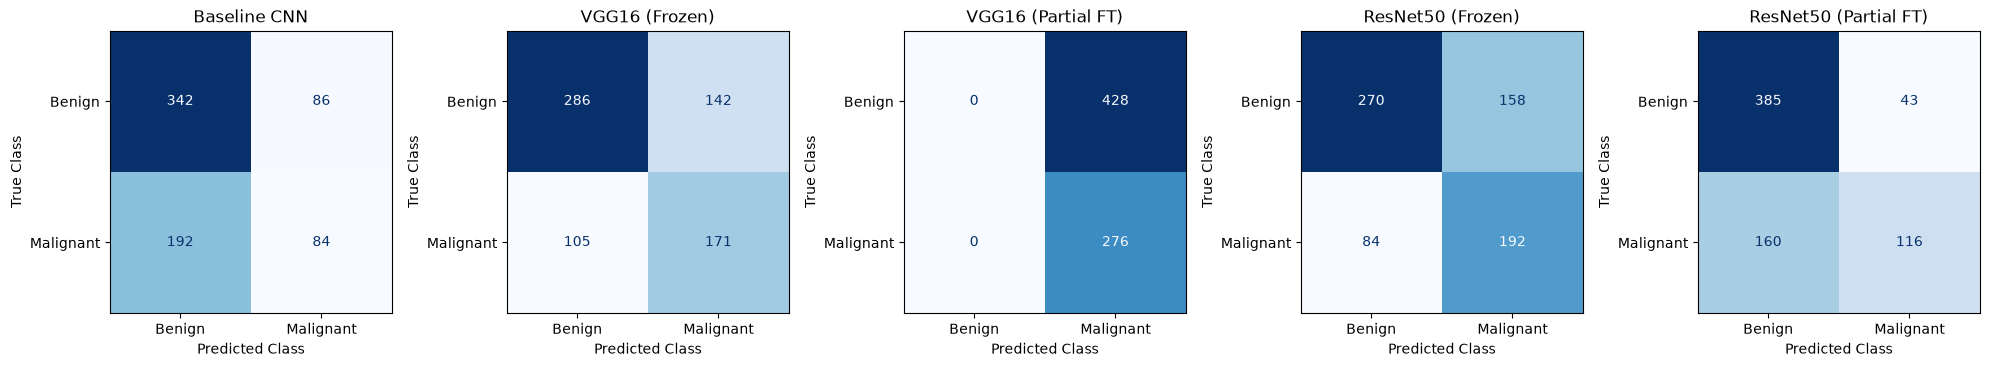

In [104]:
# =============================================================================
# 5.5 Plot Confusion Matrices
# =============================================================================
# Generate a confusion matrix for each trained model to visualise the number
# of correct and incorrect predictions for the benign and malignant classes.

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Create a figure with one subplot for each model
fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))

# Plot the confusion matrix for each model
for ax, (model_name, y_prob) in zip(axes, predictions.items()):

    # Convert predicted probabilities into binary class labels
    y_pred = (y_prob >= 0.5).astype(int)

    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Display the confusion matrix
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    ).plot(
        ax=ax,
        colorbar=False,
        cmap="Blues"
    )

    # Set subplot title
    ax.set_title(model_name)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")

# Improve figure layout
plt.tight_layout()

# Display the figure
plt.show()

## 5.6 Plot ROC Curves

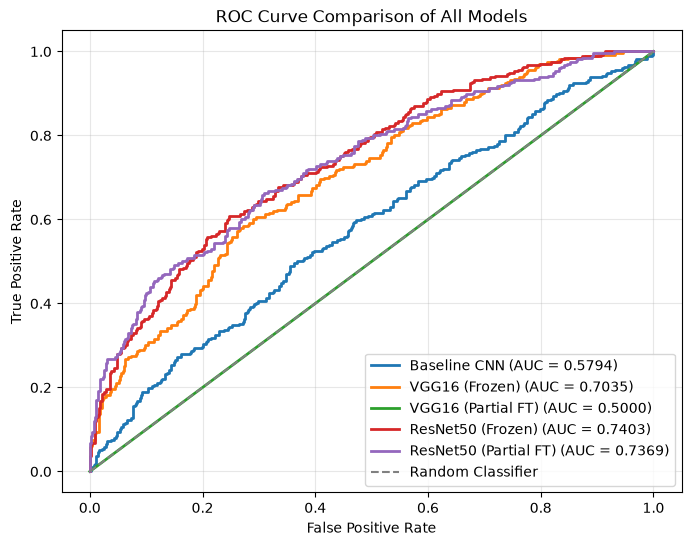

In [105]:
# =============================================================================
# 5.6 Plot ROC Curves
# =============================================================================
# Plot the Receiver Operating Characteristic (ROC) curve for each trained
# model. The ROC curve illustrates the trade-off between the True Positive
# Rate (Sensitivity) and False Positive Rate across different classification
# thresholds. The Area Under the ROC Curve (ROC-AUC) is used as the primary
# criterion for model comparison in this study.

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# Create the ROC comparison plot
plt.figure(figsize=(8, 6))

# Plot ROC curve for each model
for model_name, y_prob in predictions.items():

    # Compute False Positive Rate and True Positive Rate
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    # Compute ROC-AUC
    auc = roc_auc_score(y_true, y_prob)

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc:.4f})"
    )

# Plot the random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random Classifier"
)

# Configure plot appearance
plt.title("ROC Curve Comparison of All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Display the plot
plt.show()

## 5.7 Comparative Performance Table

## 5.8 Model Ranking and Selection

In [149]:
import os

for file in os.listdir("."):
    if file.endswith(".keras"):
        print(file)

best_baseline_cnn.keras
best_resnet50_frozen.keras
best_resnet50_partial.keras
best_vgg16_frozen.keras
best_vgg16_partial.keras


In [151]:
import tensorflow as tf
print(tf.__version__)

2.21.0
